# 02 - EDA ISOT

Saves all EDA outputs to `reports/02_eda/`.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
REPORT_DIR = ROOT / "reports" / "02_eda"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_style("whitegrid")
LABEL_NAMES = {0: "REAL", 1: "FAKE"}


In [2]:
data_path = ROOT / "data" / "processed" / "preprocessed_isot_full.csv"
if not data_path.exists():
    data_path = ROOT / "data" / "preprocessed_isot_full.csv"

if not data_path.exists():
    raise FileNotFoundError(
        "Run notebooks/01_preprocessing.ipynb first to create preprocessed_isot_full.csv."
    )

df = pd.read_csv(data_path)
df = df.dropna(subset=["processed_text", "label"]).reset_index(drop=True)
df["label"] = df["label"].astype(int)
df["label_name"] = df["label"].map(LABEL_NAMES)
df["word_count"] = df["processed_text"].astype(str).str.split().str.len()

print("Dataset shape:", df.shape)
print(df["label"].value_counts().sort_index())
print("Nulls:")
display(df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())

df.sample(10, random_state=42).to_csv(REPORT_DIR / "sample_texts.csv", index=False)
df.isnull().sum().rename("null_count").to_csv(REPORT_DIR / "null_summary.csv")
pd.Series({"duplicate_rows": int(df.duplicated().sum())}).to_csv(REPORT_DIR / "duplicate_summary.csv")


Dataset shape: (38651, 9)
label
0    21195
1    17456
Name: count, dtype: int64
Nulls:


title             0
text              0
subject           0
date              0
full_text         0
processed_text    0
label             0
label_name        0
word_count        0
dtype: int64

Duplicate rows: 0


/var/folders/bt/x0xylfv90fz2hms4m1hdtcy80000gn/T/ipykernel_51432/3454338030.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, ax=axes[0], palette=["royalblue", "tomato"])


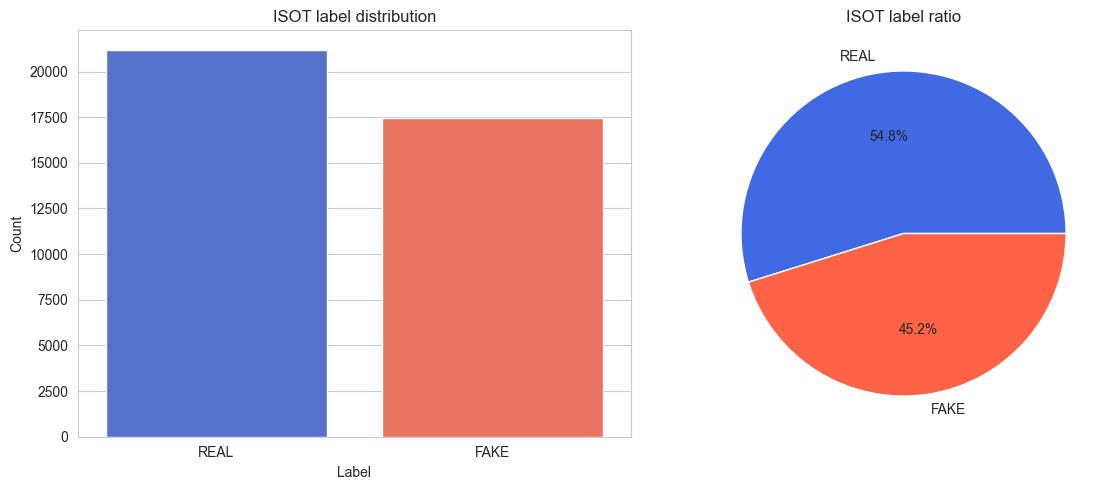

In [3]:
label_counts = df["label_name"].value_counts().reindex(["REAL", "FAKE"])
label_counts.to_csv(REPORT_DIR / "label_distribution.csv", header=["count"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(x=label_counts.index, y=label_counts.values, ax=axes[0], palette=["royalblue", "tomato"])
axes[0].set_title("ISOT label distribution")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Count")

axes[1].pie(label_counts.values, labels=label_counts.index, autopct="%1.1f%%", colors=["royalblue", "tomato"])
axes[1].set_title("ISOT label ratio")

plt.tight_layout()
plt.savefig(REPORT_DIR / "label_distribution_bar_pie.png", dpi=150, bbox_inches="tight")
plt.show()


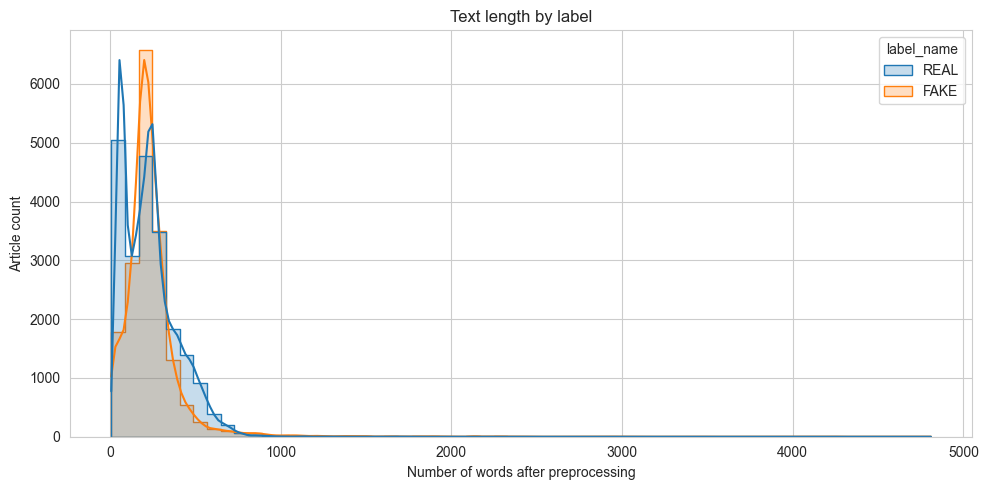

In [4]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="word_count", hue="label_name", bins=60, kde=True, element="step")
plt.title("Text length by label")
plt.xlabel("Number of words after preprocessing")
plt.ylabel("Article count")
plt.tight_layout()
plt.savefig(REPORT_DIR / "text_length_histogram.png", dpi=150, bbox_inches="tight")
plt.show()

df.groupby("label_name")["word_count"].describe().to_csv(REPORT_DIR / "text_length_summary.csv")


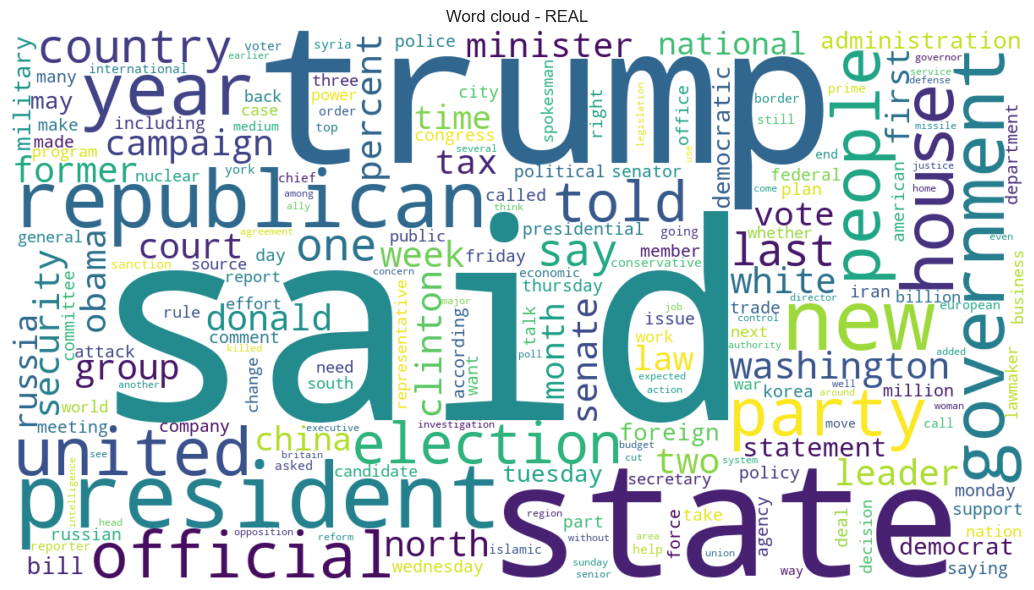

Saved: /Users/duyhung/Desktop/CHUNG/HUST/Fake-News-Detection/reports/02_eda/wordcloud_real.png


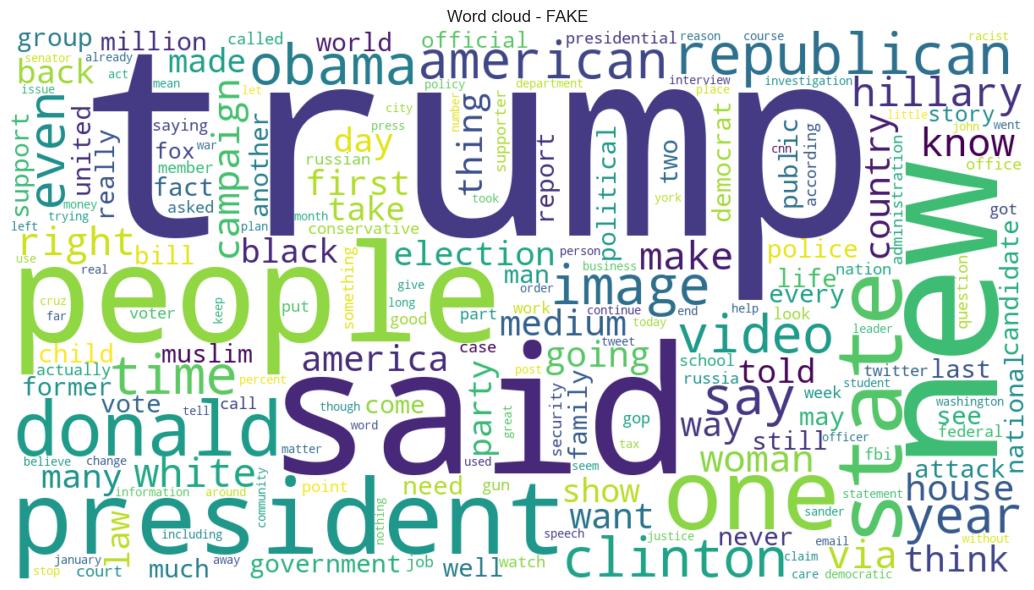

Saved: /Users/duyhung/Desktop/CHUNG/HUST/Fake-News-Detection/reports/02_eda/wordcloud_fake.png


In [5]:
for label_value, label_name in LABEL_NAMES.items():
    corpus = " ".join(df.loc[df["label"] == label_value, "processed_text"].astype(str))
    wc = WordCloud(width=1200, height=650, background_color="white", collocations=False).generate(corpus)
    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word cloud - {label_name}")
    plt.tight_layout()
    out = REPORT_DIR / f"wordcloud_{label_name.lower()}.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved:", out)


/var/folders/bt/x0xylfv90fz2hms4m1hdtcy80000gn/T/ipykernel_51432/490386640.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ngram_df, x="count", y="ngram", ax=ax, palette="viridis")


/var/folders/bt/x0xylfv90fz2hms4m1hdtcy80000gn/T/ipykernel_51432/490386640.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ngram_df, x="count", y="ngram", ax=ax, palette="viridis")


/var/folders/bt/x0xylfv90fz2hms4m1hdtcy80000gn/T/ipykernel_51432/490386640.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ngram_df, x="count", y="ngram", ax=ax, palette="viridis")


/var/folders/bt/x0xylfv90fz2hms4m1hdtcy80000gn/T/ipykernel_51432/490386640.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ngram_df, x="count", y="ngram", ax=ax, palette="viridis")


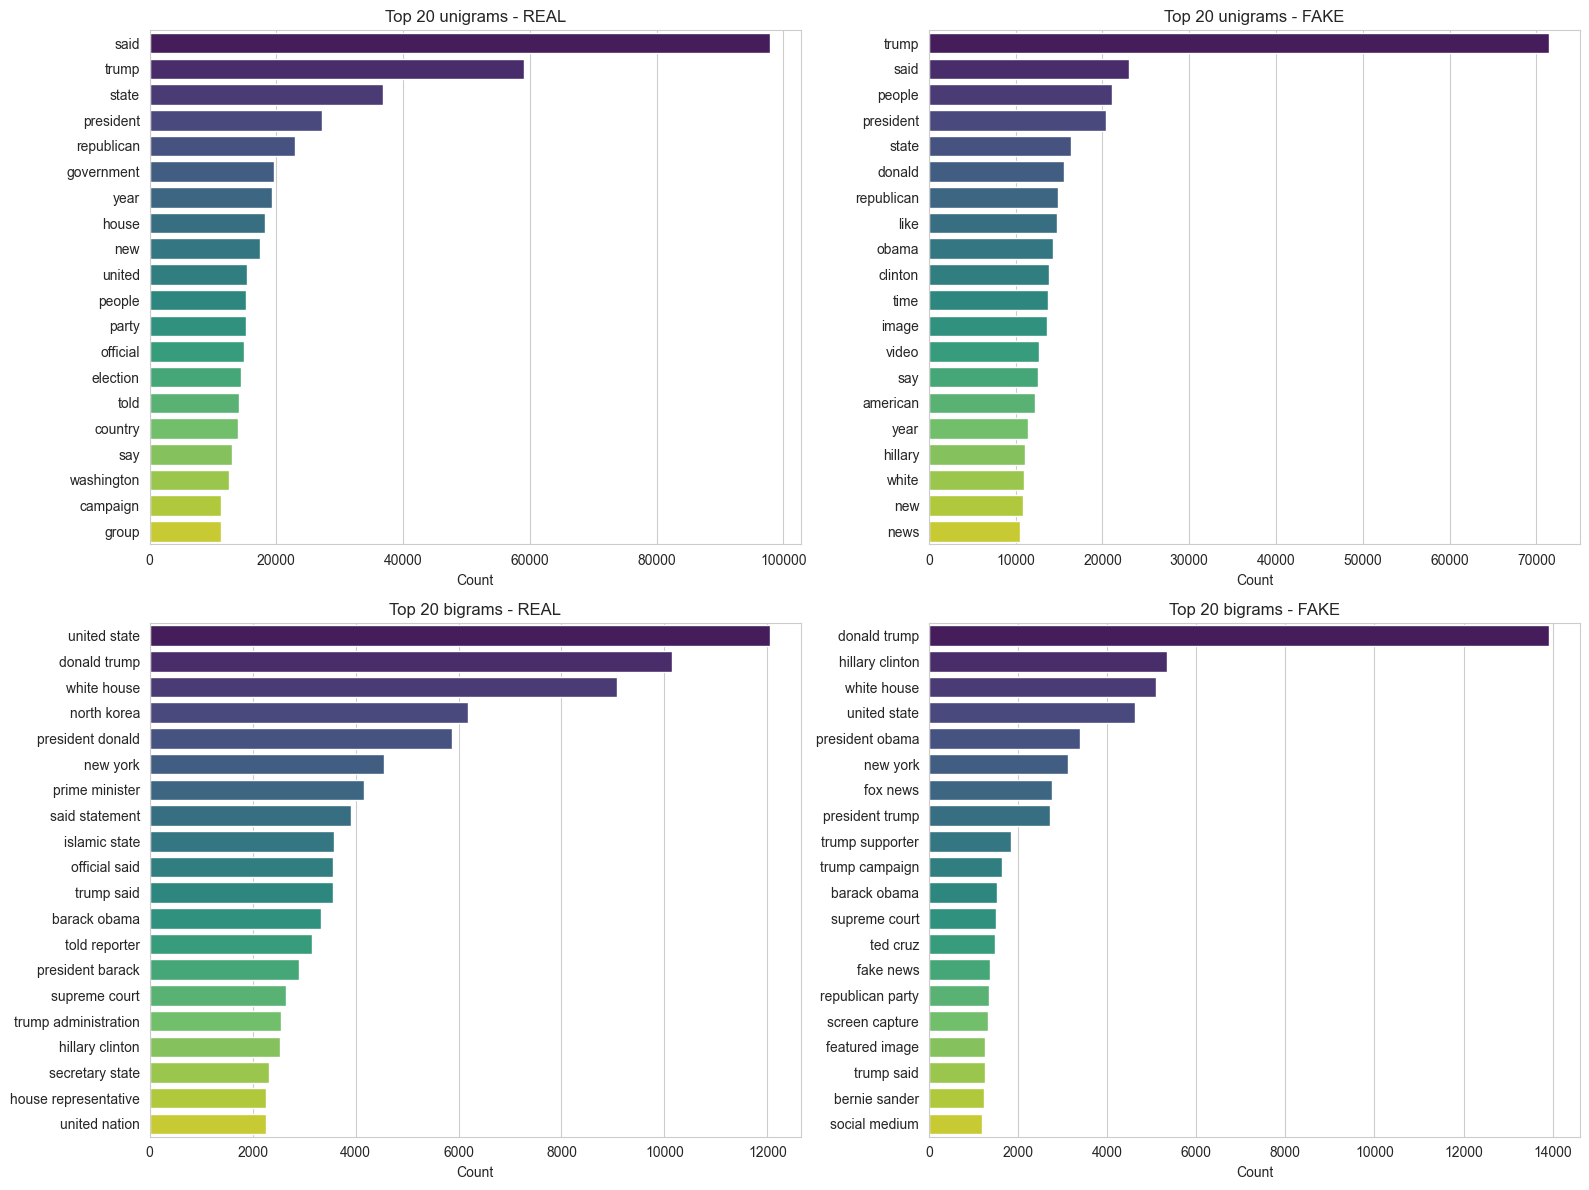

In [6]:
def top_ngrams(texts, ngram_range, top_n=20):
    vec = CountVectorizer(ngram_range=ngram_range, stop_words="english", max_features=50000)
    X = vec.fit_transform(texts.astype(str))
    counts = X.sum(axis=0).A1
    out = pd.DataFrame({"ngram": vec.get_feature_names_out(), "count": counts})
    return out.sort_values("count", ascending=False).head(top_n)


fig, axes = plt.subplots(2, 2, figsize=(16, 12))
rows = []
for col_idx, (label_value, label_name) in enumerate(LABEL_NAMES.items()):
    corpus = df.loc[df["label"] == label_value, "processed_text"]
    for row_idx, (name, ngram_range) in enumerate([("unigram", (1, 1)), ("bigram", (2, 2))]):
        ngram_df = top_ngrams(corpus, ngram_range)
        ngram_df["label"] = label_name
        ngram_df["type"] = name
        rows.append(ngram_df)
        ax = axes[row_idx, col_idx]
        sns.barplot(data=ngram_df, x="count", y="ngram", ax=ax, palette="viridis")
        ax.set_title(f"Top 20 {name}s - {label_name}")
        ax.set_xlabel("Count")
        ax.set_ylabel("")

top_df = pd.concat(rows, ignore_index=True)
top_df.to_csv(REPORT_DIR / "top_unigrams_bigrams.csv", index=False)
plt.tight_layout()
plt.savefig(REPORT_DIR / "top_unigrams_bigrams.png", dpi=150, bbox_inches="tight")
plt.show()
